In [ ]:
"""Code and script to generate a mesh file land mask from the land fraction
variables in a surface data file, and add it to an existing mesh file.

The module also contains functionality to calculate the area of each element in
a mesh file. This can be helpful, since mesh files generated by
`/tools/mkmapgrids/mkscripgrid.ncl` combined with `ESMF_Scrip2Unstruct` may miss
element areas as well as the land mask. Note that this functionality currently
is restricted to regular rectangular latitude-longitude grids only.

Attributes
----------
MESH_MASK_VAR_NAME : str
    The name of the land mask variable in the output mesh file. By default
    `elementMask`.
SURFDAT_LANDFRAC_VAR_NAMES : tuple[str, ...]
    The names of the land fraction variables in the input surface data file.
    The mesh land mask will be normally be derived from points where an of the
    land fraction variables have non-zero values.
MESH_ELEMENT_AREA_VAR_NAME : str
    The name of the element area variable in the output mesh file. `elementArea`
    by default.
MESH_ELEMENT_AREA_ATTRS : dict[str, str]
    The attributes to add to the element area variable in the output mesh file.
    By default, this includes `long_name` (`"area weights"`) and `units`
    (`"radians^2"`).

Functions
---------
create_land_mask_from_landfrac(
    source_ds: xarray.Dataset,
    *,
    landfrac_var_names: Sequence[str] = SURFDAT_LANDFRAC_VAR_NAMES,
    landmask_var_name: str = MESH_MASK_VAR_NAME,
    landfrac_threshold: float = 0.0,
    land_mask_attrs: dict[str, tp.Any] | None = None,
) -> xarray.DataArray
    Create a land mask DataArray from land fraction variables in a surface data
    Dataset. By default, points with land fraction values greater than 0.0 for
    any listed land fraction variable are considered land. The threshold can be
    customized.
compute_regular_rect_element_areas(
    mesh_ds: xarray.Dataset,
    *,
    latitudes: xarray.DataArray,
    longitudes: xarray.DataArray,
) -> xarray.DataArray
write_output_mesh_file(
    mesh_ds: xarray.Dataset,
    output_path: Path,
) -> None
    Write the modified mesh Dataset to a new netCDF file.

"""
import argparse
from collections.abc import Sequence
from pathlib import Path
import typing as tp

import xarray as xr



MESH_MASK_VAR_NAME: tp.Final[str] = 'elementMask'

MESH_LAND_MASK_ATTRS: tp.Final[dict[str, tp.Any]] = {}

SURFDAT_LANDFRAC_VAR_NAMES: tp.Final[tuple[str, ...]] = (
    'LANDFRAC_PFT',
    'LANDFRAC_MKSURFDATA',
)

MESH_ELEMENT_AREA_VAR_NAME: tp.Final[str] = 'elementArea'

MESH_ELEMENT_AREA_ATTRS: tp.Final[dict[str, str]] = {
    'long_name': 'area weights',
    'units': 'radians^2',
}


def create_land_mask_from_landfrac(
    source_ds: xr.Dataset,
    *,
    landfrac_var_names: tp.Sequence[str] = SURFDAT_LANDFRAC_VAR_NAMES,
    landmask_var_name: str = MESH_MASK_VAR_NAME,
    landfrac_threshold: float = 0.0,
    land_mask_attrs: dict[str, tp.Any] | None = None,
) -> xr.DataArray:
    """Create a land mask DataArray from land fraction variables in a surface
    data Dataset. By default, points with land fraction values greater than 0.0
    for any listed land fraction variable are considered land. The threshold
    can be customized.

    Parameters
    ----------
    source_ds : xarray.Dataset
        The input surface data Dataset containing land fraction variables.
    landfrac_var_names : Sequence[str], optional
        The names of the land fraction variables to consider, by default
        `SURFDAT_LANDFRAC_VAR_NAMES`.
    landmask_var_name : str, optional
        The name of the output land mask variable, by default
        `MESH_MASK_VAR_NAME`.
    landfrac_threshold : float, optional
        The threshold above which a land fraction value is considered land,
        by default 0.0.
    land_mask_attrs : dict[str, Any] | None, optional
        Attributes to assign to the land mask DataArray. Optional. If
        unspecified or None, the module attribute `MESH_LAND_MASK_ATTRS` is
        used.

    Returns
    -------
    xarray.DataArray
        A DataArray representing the land mask, with 1 for points containing
        land, and 0 for ocean points.
    """
    STACK_DIM: str = '__STACK_DIM__'
    if not isinstance(landfrac_var_names, tp.Sequence):
        raise TypeError(
            'landfrac_var_names must be a sequence of strings, '
            f'got {type(landfrac_var_names)}'
        )
    if isinstance(landfrac_var_names, str):
        landfrac_var_names = [landfrac_var_names]
    if not all(isinstance(name, str) for name in landfrac_var_names):
        raise TypeError(
            'all elements of landfrac_var_names must be strings'
        )
    mask_array: xr.DataArray = (
        source_ds[landfrac_var_names[0]] > landfrac_threshold
    )
    for var_name in landfrac_var_names[1:]:
        mask_array |= (source_ds[var_name] > landfrac_threshold)
    mask_array = mask_array.astype('int32')
    mask_array.name = landmask_var_name
    mask_array.attrs = (
        land_mask_attrs if land_mask_attrs is not None
        else MESH_LAND_MASK_ATTRS
    )
    return mask_array
###END def create_land_mask_from_landfrac

In [ ]:
%pwd



'/cluster/home/janko/src/CESM_repos/CTSM/tools/surfdat_landfrac_to_mesh_mask'

In [ ]:
%cd /cluster/shared/noresm/inputdata/cicero_mods/surfdata_esmf/



/cluster/shared/noresm/inputdata/cicero_mods/surfdata_esmf


In [ ]:
%ls



ctsm5.3.0/


In [ ]:
%cd ctsm5.3.0/



/cluster/shared/noresm/inputdata/cicero_mods/surfdata_esmf/ctsm5.3.0


In [ ]:
%ls



landuse.timeseries_NorwayRect_0.125x0.125_hist_1850-2023_78pfts_c251102_MISSING_HIST_LANDUSE_INPUT_FILES.nc
landuse.timeseries_NorwayRect_0.125x0.125_hist_1850-2023_78pfts_c251102.nc
landuse.timeseries_NorwayRect_0.125x0.125_hist_1850-2023_78pfts_c251102_WRONG_HIST_LANDUSE_INPUT_FILE_PATHS.nc
surfdata_0.05x0.1_hist_2005_78pfts_c251002.nc*
surfdata_NorwayRect_0.125x0.125_hist_1850_78pfts_c251102_FAILED_HIST_LANDUSE.log
surfdata_NorwayRect_0.125x0.125_hist_1850_78pfts_c251102_FAILED_HIST_LANDUSE.nc
surfdata_NorwayRect_0.125x0.125_hist_1850_78pfts_c251102.log
surfdata_NorwayRect_0.125x0.125_hist_1850_78pfts_c251102.nc


In [ ]:
xr

<module 'xarray' from '/cluster/home/janko/src/CESM_repos/CTSM/.pixi/envs/dev/lib/python3.13/site-packages/xarray/__init__.py'>

In [ ]:
surfds: xr.Dataset = xr.open_dataset('surfdata_NorwayRect_0.125x0.125_hist_1850_78pfts_c251102.nc')

In [ ]:
surfds

<xarray.Dataset> Size: 838MB
Dimensions:                  (lsmlat: 111, lsmlon: 216, nlevsoi: 10,
                              numurbl: 3, numrad: 2, nlevurb: 10, nglcecp1: 11,
                              nglcec: 10, cft: 64, natpft: 15, time: 12,
                              lsmpft: 79)
Coordinates:
  * cft                      (cft) int32 256B 15 16 17 18 19 ... 74 75 76 77 78
  * natpft                   (natpft) int32 60B 0 1 2 3 4 5 ... 9 10 11 12 13 14
  * time                     (time) int32 48B 1 2 3 4 5 6 7 8 9 10 11 12
Dimensions without coordinates: lsmlat, lsmlon, nlevsoi, numurbl, numrad,
                                nlevurb, nglcecp1, nglcec, lsmpft
Data variables: (12/82)
    LONGXY                   (lsmlat, lsmlon) float64 192kB ...
    LATIXY                   (lsmlat, lsmlon) float64 192kB ...
    mxsoil_color             int32 4B ...
    SOIL_COLOR               (lsmlat, lsmlon) int32 96kB ...
    PCT_SAND                 (nlevsoi, lsmlat, lsmlon) float32 959kB ...
    PCT_CLAY                 (nlevsoi, lsmlat, lsmlon) float32 959kB ...
    ...                       ...
    PCT_NAT_PFT              (natpft, lsmlat, lsmlon) float64 3MB ...
    PCT_CFT                  (cft, lsmlat, lsmlon) float64 12MB ...
    MONTHLY_LAI              (time, lsmpft, lsmlat, lsmlon) float64 182MB ...
    MONTHLY_SAI              (time, lsmpft, lsmlat, lsmlon) float64 182MB ...
    MONTHLY_HEIGHT_TOP       (time, lsmpft, lsmlat, lsmlon) float64 182MB ...
    MONTHLY_HEIGHT_BOT       (time, lsmpft, lsmlat, lsmlon) float64 182MB ...
Attributes: (12/46)
    Conventions:                              NCAR-CESM
    History_Log:                              created on: 11-21-25 23:40:50
    Source:                                   Community Land Model: CLM5
    Version:                                  ctsm5.3.045_noresm_v0-49-g21f48...
    Dataset_Version:                          5.3
    Logname:                                  janko
    ...                                       ...
    lai_raw_data_file_name:                   mksrf_landuse_ctsm53_pftlai_CLI...
    soil_color_raw_data_file_name:            mksrf_landuse_ctsm53_soilcolor_...
    soil_texture_mapunit_raw_data_file_name:  mksrf_soil_mapunits_5x5min_WISE...
    soil_texture_lookup_raw_data_file_name:   mksrf_soil_lookup.10level.WISE....
    fmax_raw_data_file_name:                  mksrf_fmax_0.125x0.125_c200220.nc
    VOC_EF_raw_data_file_name:                mksrf_vocef_0.5x0.5_simyr2000.c...

In [ ]:
lndmask: xr.DataArray = create_land_mask_from_landfrac(surfds)

In [ ]:
lndmask

<xarray.DataArray 'elementMask' (lsmlat: 111, lsmlon: 216)> Size: 96kB
array([[0, 0, 0, ..., 1, 1, 1],
       [0, 0, 0, ..., 1, 1, 1],
       [0, 0, 0, ..., 1, 1, 1],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(111, 216), dtype=int32)
Dimensions without coordinates: lsmlat, lsmlon

In [ ]:
lndmask.plot

ValueError: At least two variables required for a scatter plot.

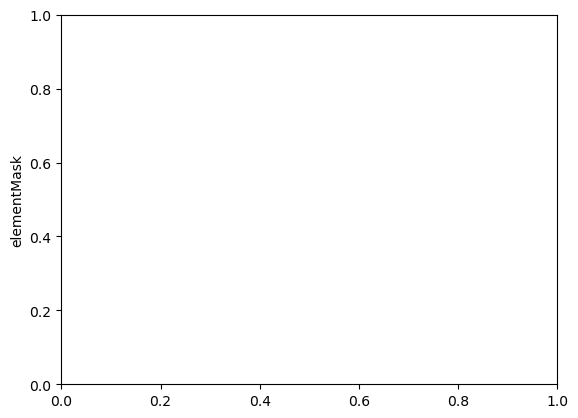

In [ ]:
lndmask.plot.scatter()

In [ ]:
lndmask

<xarray.DataArray 'elementMask' (lsmlat: 111, lsmlon: 216)> Size: 96kB
array([[0, 0, 0, ..., 1, 1, 1],
       [0, 0, 0, ..., 1, 1, 1],
       [0, 0, 0, ..., 1, 1, 1],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(111, 216), dtype=int32)
Dimensions without coordinates: lsmlat, lsmlon

In [ ]:
lndmask.plot.scatter(x='lsmlat', y='lsmlon')

In [ ]:
lndmask.plot.scatter(x='lsmlat', y='lsmlon').display()

AttributeError: 'PathCollection' object has no attribute 'display'

In [ ]:
lndmask.plot.scatter(x='lsmlat', y='lsmlon').show()

AttributeError: 'PathCollection' object has no attribute 'show'

In [ ]:
lndmask.plot

In [ ]:
help(lndmask.plot.scatter)

Help on method scatter in module xarray.plot.accessor:

scatter(
    *args: 'Any',
    x: 'Hashable | None' = None,
    y: 'Hashable | None' = None,
    z: 'Hashable | None' = None,
    hue: 'Hashable | None' = None,
    hue_style: 'HueStyleOptions' = None,
    markersize: 'Hashable | None' = None,
    linewidth: 'Hashable | None' = None,
    row: 'Hashable | None' = None,
    col: 'Hashable | None' = None,
    col_wrap: 'int | None' = None,
    ax: 'Axes | None' = None,
    figsize: 'Iterable[float] | None' = None,
    size: 'float | None' = None,
    aspect: 'float | None' = None,
    xincrease: 'bool | None' = True,
    yincrease: 'bool | None' = True,
    add_legend: 'bool | None' = None,
    add_colorbar: 'bool | None' = None,
    add_labels: 'bool | Iterable[bool]' = True,
    add_title: 'bool' = True,
    subplot_kws: 'dict[str, Any] | None' = None,
    xscale: 'ScaleOptions' = None,
    yscale: 'ScaleOptions' = None,
    xticks: 'ArrayLike | None' = None,
    yticks: 'ArrayLike

In [ ]:
lndmask

<xarray.DataArray 'elementMask' (lsmlat: 111, lsmlon: 216)> Size: 96kB
array([[0, 0, 0, ..., 1, 1, 1],
       [0, 0, 0, ..., 1, 1, 1],
       [0, 0, 0, ..., 1, 1, 1],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(111, 216), dtype=int32)
Dimensions without coordinates: lsmlat, lsmlon

In [ ]:
lndmask['lsmlat']

<xarray.DataArray 'lsmlat' (lsmlat: 111)> Size: 888B
[111 values with dtype=int64]
Dimensions without coordinates: lsmlat

In [ ]:
lndmask['lsmlat'].data

array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
        26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
        39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
        52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
        65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
        78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
        91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103,
       104, 105, 106, 107, 108, 109, 110])

In [ ]:
help(lndmask.plot.scatter)

Help on method scatter in module xarray.plot.accessor:

scatter(
    *args: 'Any',
    x: 'Hashable | None' = None,
    y: 'Hashable | None' = None,
    z: 'Hashable | None' = None,
    hue: 'Hashable | None' = None,
    hue_style: 'HueStyleOptions' = None,
    markersize: 'Hashable | None' = None,
    linewidth: 'Hashable | None' = None,
    row: 'Hashable | None' = None,
    col: 'Hashable | None' = None,
    col_wrap: 'int | None' = None,
    ax: 'Axes | None' = None,
    figsize: 'Iterable[float] | None' = None,
    size: 'float | None' = None,
    aspect: 'float | None' = None,
    xincrease: 'bool | None' = True,
    yincrease: 'bool | None' = True,
    add_legend: 'bool | None' = None,
    add_colorbar: 'bool | None' = None,
    add_labels: 'bool | Iterable[bool]' = True,
    add_title: 'bool' = True,
    subplot_kws: 'dict[str, Any] | None' = None,
    xscale: 'ScaleOptions' = None,
    yscale: 'ScaleOptions' = None,
    xticks: 'ArrayLike | None' = None,
    yticks: 'ArrayLike

In [ ]:
lndmask.dims[1]

'lsmlon'

In [ ]:
surfds

<xarray.Dataset> Size: 838MB
Dimensions:                  (lsmlat: 111, lsmlon: 216, nlevsoi: 10,
                              numurbl: 3, numrad: 2, nlevurb: 10, nglcecp1: 11,
                              nglcec: 10, cft: 64, natpft: 15, time: 12,
                              lsmpft: 79)
Coordinates:
  * cft                      (cft) int32 256B 15 16 17 18 19 ... 74 75 76 77 78
  * natpft                   (natpft) int32 60B 0 1 2 3 4 5 ... 9 10 11 12 13 14
  * time                     (time) int32 48B 1 2 3 4 5 6 7 8 9 10 11 12
Dimensions without coordinates: lsmlat, lsmlon, nlevsoi, numurbl, numrad,
                                nlevurb, nglcecp1, nglcec, lsmpft
Data variables: (12/82)
    LONGXY                   (lsmlat, lsmlon) float64 192kB ...
    LATIXY                   (lsmlat, lsmlon) float64 192kB ...
    mxsoil_color             int32 4B ...
    SOIL_COLOR               (lsmlat, lsmlon) int32 96kB ...
    PCT_SAND                 (nlevsoi, lsmlat, lsmlon) float32 959kB ...
    PCT_CLAY                 (nlevsoi, lsmlat, lsmlon) float32 959kB ...
    ...                       ...
    PCT_NAT_PFT              (natpft, lsmlat, lsmlon) float64 3MB ...
    PCT_CFT                  (cft, lsmlat, lsmlon) float64 12MB ...
    MONTHLY_LAI              (time, lsmpft, lsmlat, lsmlon) float64 182MB ...
    MONTHLY_SAI              (time, lsmpft, lsmlat, lsmlon) float64 182MB ...
    MONTHLY_HEIGHT_TOP       (time, lsmpft, lsmlat, lsmlon) float64 182MB ...
    MONTHLY_HEIGHT_BOT       (time, lsmpft, lsmlat, lsmlon) float64 182MB ...
Attributes: (12/46)
    Conventions:                              NCAR-CESM
    History_Log:                              created on: 11-21-25 23:40:50
    Source:                                   Community Land Model: CLM5
    Version:                                  ctsm5.3.045_noresm_v0-49-g21f48...
    Dataset_Version:                          5.3
    Logname:                                  janko
    ...                                       ...
    lai_raw_data_file_name:                   mksrf_landuse_ctsm53_pftlai_CLI...
    soil_color_raw_data_file_name:            mksrf_landuse_ctsm53_soilcolor_...
    soil_texture_mapunit_raw_data_file_name:  mksrf_soil_mapunits_5x5min_WISE...
    soil_texture_lookup_raw_data_file_name:   mksrf_soil_lookup.10level.WISE....
    fmax_raw_data_file_name:                  mksrf_fmax_0.125x0.125_c200220.nc
    VOC_EF_raw_data_file_name:                mksrf_vocef_0.5x0.5_simyr2000.c...

In [ ]:
[_var for _var in surfds.variables if 'lat' in _var.lower()]

['LATIXY']

In [ ]:
%whos



Variable                         Type         Data/Info
-------------------------------------------------------
MESH_ELEMENT_AREA_ATTRS          dict         n=2
MESH_ELEMENT_AREA_VAR_NAME       str          elementArea
MESH_LAND_MASK_ATTRS             dict         n=0
MESH_MASK_VAR_NAME               str          elementMask
Path                             type         <class 'pathlib._local.Path'>
SURFDAT_LANDFRAC_VAR_NAMES       tuple        n=2
Sequence                         ABCMeta      <class 'collections.abc.Sequence'>
argparse                         module       <module 'argparse' from '<...>/python3.13/argparse.py'>
create_land_mask_from_landfrac   function     <function create_land_mas<...>ndfrac at 0x7f1d50117060>
get_ipython                      function     <function get_ipython at 0x7f1d55342d40>
lndmask                          DataArray    <xarray.DataArray 'elemen<...>ordinates: lsmlat, lsmlon
os                               module       <module 'os' (frozen)>
sur

In [ ]:
%pwd



'/cluster/shared/noresm/inputdata/cicero_mods/surfdata_esmf/ctsm5.3.0'

In [ ]:
%cd ../../share/meshes/



/cluster/shared/noresm/inputdata/cicero_mods/share/meshes


In [ ]:
%ls



ESMFmesh_NorwayRect_0.125x0.125_nomask_c251031.nc


In [ ]:
normesh = xr.open_dataset('ESMFmesh_NorwayRect_0.125x0.125_nomask_c251031.nc')

In [ ]:
normesh

<xarray.Dataset> Size: 2MB
Dimensions:         (origGridRank: 2, nodeCount: 24304, coordDim: 2,
                     elementCount: 23976, maxNodePElement: 4)
Dimensions without coordinates: origGridRank, nodeCount, coordDim,
                                elementCount, maxNodePElement
Data variables:
    origGridDims    (origGridRank) int32 8B ...
    nodeCoords      (nodeCount, coordDim) float64 389kB ...
    elementConn     (elementCount, maxNodePElement) float64 767kB ...
    numElementConn  (elementCount) int32 96kB ...
    centerCoords    (elementCount, coordDim) float64 384kB ...
    elementMask     (elementCount) int32 96kB ...
Attributes:
    gridType:       unstructured mesh
    version:        0.9
    inputFile:      ./SCRIPgrid_NorwayRect_0.125x0.125_nomask_c251026.nc
    timeGenerated:  Fri Oct 31 12:18:05 2025

In [ ]:
lndmask

<xarray.DataArray 'elementMask' (lsmlat: 111, lsmlon: 216)> Size: 96kB
array([[0, 0, 0, ..., 1, 1, 1],
       [0, 0, 0, ..., 1, 1, 1],
       [0, 0, 0, ..., 1, 1, 1],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(111, 216), dtype=int32)
Dimensions without coordinates: lsmlat, lsmlon

In [ ]:
normesh['centerLat'] = normesh['centerCoords'].sel(coordDim=1)

In [ ]:
normesh

<xarray.Dataset> Size: 2MB
Dimensions:         (origGridRank: 2, nodeCount: 24304, coordDim: 2,
                     elementCount: 23976, maxNodePElement: 4)
Dimensions without coordinates: origGridRank, nodeCount, coordDim,
                                elementCount, maxNodePElement
Data variables:
    origGridDims    (origGridRank) int32 8B ...
    nodeCoords      (nodeCount, coordDim) float64 389kB ...
    elementConn     (elementCount, maxNodePElement) float64 767kB ...
    numElementConn  (elementCount) int32 96kB ...
    centerCoords    (elementCount, coordDim) float64 384kB ...
    elementMask     (elementCount) int32 96kB ...
    centerLat       (elementCount) float64 192kB ...
Attributes:
    gridType:       unstructured mesh
    version:        0.9
    inputFile:      ./SCRIPgrid_NorwayRect_0.125x0.125_nomask_c251026.nc
    timeGenerated:  Fri Oct 31 12:18:05 2025

In [ ]:
normesh['centerLon'] = normesh['centerCoords'].sel(coordDim=0)

In [ ]:
normesh['centerLon']

<xarray.DataArray 'centerLon' (elementCount: 23976)> Size: 192kB
[23976 values with dtype=float64]
Dimensions without coordinates: elementCount
Attributes:
    units:    degrees

In [ ]:
normesh['centerLon'].data

array([ 4.375,  4.5  ,  4.625, ..., 31.   , 31.125, 31.25 ],
      shape=(23976,))

In [ ]:
normesh

<xarray.Dataset> Size: 2MB
Dimensions:         (origGridRank: 2, nodeCount: 24304, coordDim: 2,
                     elementCount: 23976, maxNodePElement: 4)
Dimensions without coordinates: origGridRank, nodeCount, coordDim,
                                elementCount, maxNodePElement
Data variables:
    origGridDims    (origGridRank) int32 8B ...
    nodeCoords      (nodeCount, coordDim) float64 389kB ...
    elementConn     (elementCount, maxNodePElement) float64 767kB ...
    numElementConn  (elementCount) int32 96kB ...
    centerCoords    (elementCount, coordDim) float64 384kB ...
    elementMask     (elementCount) int32 96kB ...
    centerLat       (elementCount) float64 192kB ...
    centerLon       (elementCount) float64 192kB 4.375 4.5 4.625 ... 31.12 31.25
Attributes:
    gridType:       unstructured mesh
    version:        0.9
    inputFile:      ./SCRIPgrid_NorwayRect_0.125x0.125_nomask_c251026.nc
    timeGenerated:  Fri Oct 31 12:18:05 2025

In [ ]:
normesh_coords.assign_coords(elementCount='centerLat', elementCount='centerLon')

SyntaxError: keyword argument repeated: elementCount (<ipython-input-40-2f34ba08bc21>, line 1)

In [ ]:
normesh_coords.assign_coords(elementCount='centerLat').assign_coords(elementCount='centerLon')

NameError: name 'normesh_coords' is not defined

In [ ]:
normesh_coords = normesh.assign_coords(elementCount='centerLat').assign_coords(elementCount='centerLon')

ValueError: dimension 'elementCount' already exists as a scalar variable

In [ ]:
normesh

<xarray.Dataset> Size: 2MB
Dimensions:         (origGridRank: 2, nodeCount: 24304, coordDim: 2,
                     elementCount: 23976, maxNodePElement: 4)
Dimensions without coordinates: origGridRank, nodeCount, coordDim,
                                elementCount, maxNodePElement
Data variables:
    origGridDims    (origGridRank) int32 8B ...
    nodeCoords      (nodeCount, coordDim) float64 389kB ...
    elementConn     (elementCount, maxNodePElement) float64 767kB ...
    numElementConn  (elementCount) int32 96kB ...
    centerCoords    (elementCount, coordDim) float64 384kB ...
    elementMask     (elementCount) int32 96kB ...
    centerLat       (elementCount) float64 192kB ...
    centerLon       (elementCount) float64 192kB 4.375 4.5 4.625 ... 31.12 31.25
Attributes:
    gridType:       unstructured mesh
    version:        0.9
    inputFile:      ./SCRIPgrid_NorwayRect_0.125x0.125_nomask_c251026.nc
    timeGenerated:  Fri Oct 31 12:18:05 2025

In [ ]:
normesh.set_coords(['centerLat', 'centerLon'])

<xarray.Dataset> Size: 2MB
Dimensions:         (origGridRank: 2, nodeCount: 24304, coordDim: 2,
                     elementCount: 23976, maxNodePElement: 4)
Coordinates:
    centerLat       (elementCount) float64 192kB ...
    centerLon       (elementCount) float64 192kB 4.375 4.5 4.625 ... 31.12 31.25
Dimensions without coordinates: origGridRank, nodeCount, coordDim,
                                elementCount, maxNodePElement
Data variables:
    origGridDims    (origGridRank) int32 8B ...
    nodeCoords      (nodeCount, coordDim) float64 389kB ...
    elementConn     (elementCount, maxNodePElement) float64 767kB ...
    numElementConn  (elementCount) int32 96kB ...
    centerCoords    (elementCount, coordDim) float64 384kB ...
    elementMask     (elementCount) int32 96kB ...
Attributes:
    gridType:       unstructured mesh
    version:        0.9
    inputFile:      ./SCRIPgrid_NorwayRect_0.125x0.125_nomask_c251026.nc
    timeGenerated:  Fri Oct 31 12:18:05 2025

In [ ]:
fmesh

NameError: name 'fmesh' is not defined

In [ ]:
normesh

<xarray.Dataset> Size: 2MB
Dimensions:         (origGridRank: 2, nodeCount: 24304, coordDim: 2,
                     elementCount: 23976, maxNodePElement: 4)
Dimensions without coordinates: origGridRank, nodeCount, coordDim,
                                elementCount, maxNodePElement
Data variables:
    origGridDims    (origGridRank) int32 8B ...
    nodeCoords      (nodeCount, coordDim) float64 389kB ...
    elementConn     (elementCount, maxNodePElement) float64 767kB ...
    numElementConn  (elementCount) int32 96kB ...
    centerCoords    (elementCount, coordDim) float64 384kB ...
    elementMask     (elementCount) int32 96kB ...
    centerLat       (elementCount) float64 192kB ...
    centerLon       (elementCount) float64 192kB 4.375 4.5 4.625 ... 31.12 31.25
Attributes:
    gridType:       unstructured mesh
    version:        0.9
    inputFile:      ./SCRIPgrid_NorwayRect_0.125x0.125_nomask_c251026.nc
    timeGenerated:  Fri Oct 31 12:18:05 2025

In [ ]:
normesh_coords

NameError: name 'normesh_coords' is not defined

In [ ]:
normesh

<xarray.Dataset> Size: 2MB
Dimensions:         (origGridRank: 2, nodeCount: 24304, coordDim: 2,
                     elementCount: 23976, maxNodePElement: 4)
Dimensions without coordinates: origGridRank, nodeCount, coordDim,
                                elementCount, maxNodePElement
Data variables:
    origGridDims    (origGridRank) int32 8B ...
    nodeCoords      (nodeCount, coordDim) float64 389kB ...
    elementConn     (elementCount, maxNodePElement) float64 767kB ...
    numElementConn  (elementCount) int32 96kB ...
    centerCoords    (elementCount, coordDim) float64 384kB ...
    elementMask     (elementCount) int32 96kB ...
    centerLat       (elementCount) float64 192kB ...
    centerLon       (elementCount) float64 192kB 4.375 4.5 4.625 ... 31.12 31.25
Attributes:
    gridType:       unstructured mesh
    version:        0.9
    inputFile:      ./SCRIPgrid_NorwayRect_0.125x0.125_nomask_c251026.nc
    timeGenerated:  Fri Oct 31 12:18:05 2025

In [ ]:
normesh.set_index(elementCount=['centerLon', 'centerLat'])

<xarray.Dataset> Size: 2MB
Dimensions:         (origGridRank: 2, nodeCount: 24304, coordDim: 2,
                     elementCount: 23976, maxNodePElement: 4)
Coordinates:
  * elementCount    (elementCount) object 192kB MultiIndex
  * centerLon       (elementCount) float64 192kB 4.375 4.5 4.625 ... 31.12 31.25
  * centerLat       (elementCount) float64 192kB 57.5 57.5 57.5 ... 71.25 71.25
Dimensions without coordinates: origGridRank, nodeCount, coordDim,
                                maxNodePElement
Data variables:
    origGridDims    (origGridRank) int32 8B ...
    nodeCoords      (nodeCount, coordDim) float64 389kB ...
    elementConn     (elementCount, maxNodePElement) float64 767kB ...
    numElementConn  (elementCount) int32 96kB ...
    centerCoords    (elementCount, coordDim) float64 384kB ...
    elementMask     (elementCount) int32 96kB ...
Attributes:
    gridType:       unstructured mesh
    version:        0.9
    inputFile:      ./SCRIPgrid_NorwayRect_0.125x0.125_nomask_c251026.nc
    timeGenerated:  Fri Oct 31 12:18:05 2025

In [ ]:
normesh_indexed = normesh.set_index(elementCount=['centerLon', 'centerLat'])

In [ ]:
lndmask

<xarray.DataArray 'elementMask' (lsmlat: 111, lsmlon: 216)> Size: 96kB
array([[0, 0, 0, ..., 1, 1, 1],
       [0, 0, 0, ..., 1, 1, 1],
       [0, 0, 0, ..., 1, 1, 1],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(111, 216), dtype=int32)
Dimensions without coordinates: lsmlat, lsmlon

In [ ]:
surfds

<xarray.Dataset> Size: 838MB
Dimensions:                  (lsmlat: 111, lsmlon: 216, nlevsoi: 10,
                              numurbl: 3, numrad: 2, nlevurb: 10, nglcecp1: 11,
                              nglcec: 10, cft: 64, natpft: 15, time: 12,
                              lsmpft: 79)
Coordinates:
  * cft                      (cft) int32 256B 15 16 17 18 19 ... 74 75 76 77 78
  * natpft                   (natpft) int32 60B 0 1 2 3 4 5 ... 9 10 11 12 13 14
  * time                     (time) int32 48B 1 2 3 4 5 6 7 8 9 10 11 12
Dimensions without coordinates: lsmlat, lsmlon, nlevsoi, numurbl, numrad,
                                nlevurb, nglcecp1, nglcec, lsmpft
Data variables: (12/82)
    LONGXY                   (lsmlat, lsmlon) float64 192kB ...
    LATIXY                   (lsmlat, lsmlon) float64 192kB ...
    mxsoil_color             int32 4B ...
    SOIL_COLOR               (lsmlat, lsmlon) int32 96kB ...
    PCT_SAND                 (nlevsoi, lsmlat, lsmlon) float32 959kB ...
    PCT_CLAY                 (nlevsoi, lsmlat, lsmlon) float32 959kB ...
    ...                       ...
    PCT_NAT_PFT              (natpft, lsmlat, lsmlon) float64 3MB ...
    PCT_CFT                  (cft, lsmlat, lsmlon) float64 12MB ...
    MONTHLY_LAI              (time, lsmpft, lsmlat, lsmlon) float64 182MB ...
    MONTHLY_SAI              (time, lsmpft, lsmlat, lsmlon) float64 182MB ...
    MONTHLY_HEIGHT_TOP       (time, lsmpft, lsmlat, lsmlon) float64 182MB ...
    MONTHLY_HEIGHT_BOT       (time, lsmpft, lsmlat, lsmlon) float64 182MB ...
Attributes: (12/46)
    Conventions:                              NCAR-CESM
    History_Log:                              created on: 11-21-25 23:40:50
    Source:                                   Community Land Model: CLM5
    Version:                                  ctsm5.3.045_noresm_v0-49-g21f48...
    Dataset_Version:                          5.3
    Logname:                                  janko
    ...                                       ...
    lai_raw_data_file_name:                   mksrf_landuse_ctsm53_pftlai_CLI...
    soil_color_raw_data_file_name:            mksrf_landuse_ctsm53_soilcolor_...
    soil_texture_mapunit_raw_data_file_name:  mksrf_soil_mapunits_5x5min_WISE...
    soil_texture_lookup_raw_data_file_name:   mksrf_soil_lookup.10level.WISE....
    fmax_raw_data_file_name:                  mksrf_fmax_0.125x0.125_c200220.nc
    VOC_EF_raw_data_file_name:                mksrf_vocef_0.5x0.5_simyr2000.c...

In [ ]:
surfds_stacked = surfds.stack(elementCount=['lsmlon', 'lsmlat'])

In [ ]:
surfds_stacked

<xarray.Dataset> Size: 838MB
Dimensions:                  (elementCount: 23976, nlevsoi: 10, numurbl: 3,
                              numrad: 2, nlevurb: 10, nglcecp1: 11, nglcec: 10,
                              cft: 64, natpft: 15, time: 12, lsmpft: 79)
Coordinates:
  * elementCount             (elementCount) object 192kB MultiIndex
  * cft                      (cft) int32 256B 15 16 17 18 19 ... 74 75 76 77 78
  * natpft                   (natpft) int32 60B 0 1 2 3 4 5 ... 9 10 11 12 13 14
  * time                     (time) int32 48B 1 2 3 4 5 6 7 8 9 10 11 12
  * lsmlon                   (elementCount) int64 192kB 0 0 0 0 ... 215 215 215
  * lsmlat                   (elementCount) int64 192kB 0 1 2 3 ... 108 109 110
Dimensions without coordinates: nlevsoi, numurbl, numrad, nlevurb, nglcecp1,
                                nglcec, lsmpft
Data variables: (12/82)
    LONGXY                   (elementCount) float64 192kB 4.375 4.375 ... 31.25
    LATIXY                   (elementCount) float64 192kB 57.5 57.62 ... 71.25
    mxsoil_color             int32 4B ...
    SOIL_COLOR               (elementCount) int32 96kB 15 15 15 15 ... 15 15 15
    PCT_SAND                 (nlevsoi, elementCount) float32 959kB 43.0 ... 43.0
    PCT_CLAY                 (nlevsoi, elementCount) float32 959kB 18.0 ... 18.0
    ...                       ...
    PCT_NAT_PFT              (natpft, elementCount) float64 3MB 100.0 ... 0.0
    PCT_CFT                  (cft, elementCount) float64 12MB 100.0 ... 0.0
    MONTHLY_LAI              (time, lsmpft, elementCount) float64 182MB 0.0 ....
    MONTHLY_SAI              (time, lsmpft, elementCount) float64 182MB 0.0 ....
    MONTHLY_HEIGHT_TOP       (time, lsmpft, elementCount) float64 182MB 0.0 ....
    MONTHLY_HEIGHT_BOT       (time, lsmpft, elementCount) float64 182MB 0.0 ....
Attributes: (12/46)
    Conventions:                              NCAR-CESM
    History_Log:                              created on: 11-21-25 23:40:50
    Source:                                   Community Land Model: CLM5
    Version:                                  ctsm5.3.045_noresm_v0-49-g21f48...
    Dataset_Version:                          5.3
    Logname:                                  janko
    ...                                       ...
    lai_raw_data_file_name:                   mksrf_landuse_ctsm53_pftlai_CLI...
    soil_color_raw_data_file_name:            mksrf_landuse_ctsm53_soilcolor_...
    soil_texture_mapunit_raw_data_file_name:  mksrf_soil_mapunits_5x5min_WISE...
    soil_texture_lookup_raw_data_file_name:   mksrf_soil_lookup.10level.WISE....
    fmax_raw_data_file_name:                  mksrf_fmax_0.125x0.125_c200220.nc
    VOC_EF_raw_data_file_name:                mksrf_vocef_0.5x0.5_simyr2000.c...

In [ ]:
surfds_stacked = surfds_stacked.rename_vars(lsmlon='centerLon', lsmlat='centerLat')

In [ ]:
surfds_stacked

<xarray.Dataset> Size: 838MB
Dimensions:                  (elementCount: 23976, nlevsoi: 10, numurbl: 3,
                              numrad: 2, nlevurb: 10, nglcecp1: 11, nglcec: 10,
                              cft: 64, natpft: 15, time: 12, lsmpft: 79)
Coordinates:
  * elementCount             (elementCount) object 192kB MultiIndex
  * cft                      (cft) int32 256B 15 16 17 18 19 ... 74 75 76 77 78
  * natpft                   (natpft) int32 60B 0 1 2 3 4 5 ... 9 10 11 12 13 14
  * time                     (time) int32 48B 1 2 3 4 5 6 7 8 9 10 11 12
  * centerLon                (elementCount) int64 192kB 0 0 0 0 ... 215 215 215
  * centerLat                (elementCount) int64 192kB 0 1 2 3 ... 108 109 110
Dimensions without coordinates: nlevsoi, numurbl, numrad, nlevurb, nglcecp1,
                                nglcec, lsmpft
Data variables: (12/82)
    LONGXY                   (elementCount) float64 192kB 4.375 4.375 ... 31.25
    LATIXY                   (elementCount) float64 192kB 57.5 57.62 ... 71.25
    mxsoil_color             int32 4B ...
    SOIL_COLOR               (elementCount) int32 96kB 15 15 15 15 ... 15 15 15
    PCT_SAND                 (nlevsoi, elementCount) float32 959kB 43.0 ... 43.0
    PCT_CLAY                 (nlevsoi, elementCount) float32 959kB 18.0 ... 18.0
    ...                       ...
    PCT_NAT_PFT              (natpft, elementCount) float64 3MB 100.0 ... 0.0
    PCT_CFT                  (cft, elementCount) float64 12MB 100.0 ... 0.0
    MONTHLY_LAI              (time, lsmpft, elementCount) float64 182MB 0.0 ....
    MONTHLY_SAI              (time, lsmpft, elementCount) float64 182MB 0.0 ....
    MONTHLY_HEIGHT_TOP       (time, lsmpft, elementCount) float64 182MB 0.0 ....
    MONTHLY_HEIGHT_BOT       (time, lsmpft, elementCount) float64 182MB 0.0 ....
Attributes: (12/46)
    Conventions:                              NCAR-CESM
    History_Log:                              created on: 11-21-25 23:40:50
    Source:                                   Community Land Model: CLM5
    Version:                                  ctsm5.3.045_noresm_v0-49-g21f48...
    Dataset_Version:                          5.3
    Logname:                                  janko
    ...                                       ...
    lai_raw_data_file_name:                   mksrf_landuse_ctsm53_pftlai_CLI...
    soil_color_raw_data_file_name:            mksrf_landuse_ctsm53_soilcolor_...
    soil_texture_mapunit_raw_data_file_name:  mksrf_soil_mapunits_5x5min_WISE...
    soil_texture_lookup_raw_data_file_name:   mksrf_soil_lookup.10level.WISE....
    fmax_raw_data_file_name:                  mksrf_fmax_0.125x0.125_c200220.nc
    VOC_EF_raw_data_file_name:                mksrf_vocef_0.5x0.5_simyr2000.c...

In [ ]:
surfds_indexed = surfds.set_index(elementCount=['centerLon', 'centerLat'])

ValueError: centerLon, centerLat variable(s) do not exist

In [ ]:
surfds_indexed = surfds_stacked.set_index(elementCount=['centerLon', 'centerLat'])

In [ ]:
surfds_indexed

<xarray.Dataset> Size: 838MB
Dimensions:                  (elementCount: 23976, nlevsoi: 10, numurbl: 3,
                              numrad: 2, nlevurb: 10, nglcecp1: 11, nglcec: 10,
                              cft: 64, natpft: 15, time: 12, lsmpft: 79)
Coordinates:
  * elementCount             (elementCount) object 192kB MultiIndex
  * cft                      (cft) int32 256B 15 16 17 18 19 ... 74 75 76 77 78
  * natpft                   (natpft) int32 60B 0 1 2 3 4 5 ... 9 10 11 12 13 14
  * time                     (time) int32 48B 1 2 3 4 5 6 7 8 9 10 11 12
  * centerLon                (elementCount) int64 192kB 0 0 0 0 ... 215 215 215
  * centerLat                (elementCount) int64 192kB 0 1 2 3 ... 108 109 110
Dimensions without coordinates: nlevsoi, numurbl, numrad, nlevurb, nglcecp1,
                                nglcec, lsmpft
Data variables: (12/82)
    LONGXY                   (elementCount) float64 192kB 4.375 4.375 ... 31.25
    LATIXY                   (elementCount) float64 192kB 57.5 57.62 ... 71.25
    mxsoil_color             int32 4B ...
    SOIL_COLOR               (elementCount) int32 96kB 15 15 15 15 ... 15 15 15
    PCT_SAND                 (nlevsoi, elementCount) float32 959kB 43.0 ... 43.0
    PCT_CLAY                 (nlevsoi, elementCount) float32 959kB 18.0 ... 18.0
    ...                       ...
    PCT_NAT_PFT              (natpft, elementCount) float64 3MB 100.0 ... 0.0
    PCT_CFT                  (cft, elementCount) float64 12MB 100.0 ... 0.0
    MONTHLY_LAI              (time, lsmpft, elementCount) float64 182MB 0.0 ....
    MONTHLY_SAI              (time, lsmpft, elementCount) float64 182MB 0.0 ....
    MONTHLY_HEIGHT_TOP       (time, lsmpft, elementCount) float64 182MB 0.0 ....
    MONTHLY_HEIGHT_BOT       (time, lsmpft, elementCount) float64 182MB 0.0 ....
Attributes: (12/46)
    Conventions:                              NCAR-CESM
    History_Log:                              created on: 11-21-25 23:40:50
    Source:                                   Community Land Model: CLM5
    Version:                                  ctsm5.3.045_noresm_v0-49-g21f48...
    Dataset_Version:                          5.3
    Logname:                                  janko
    ...                                       ...
    lai_raw_data_file_name:                   mksrf_landuse_ctsm53_pftlai_CLI...
    soil_color_raw_data_file_name:            mksrf_landuse_ctsm53_soilcolor_...
    soil_texture_mapunit_raw_data_file_name:  mksrf_soil_mapunits_5x5min_WISE...
    soil_texture_lookup_raw_data_file_name:   mksrf_soil_lookup.10level.WISE....
    fmax_raw_data_file_name:                  mksrf_fmax_0.125x0.125_c200220.nc
    VOC_EF_raw_data_file_name:                mksrf_vocef_0.5x0.5_simyr2000.c...

In [ ]:
lndmask = create_land_mask_from_landfrac(surfds_indexed)

In [ ]:
lndmask

<xarray.DataArray 'elementMask' (elementCount: 23976)> Size: 96kB
array([0, 0, 0, ..., 0, 0, 0], shape=(23976,), dtype=int32)
Coordinates:
  * elementCount  (elementCount) object 192kB MultiIndex
  * centerLon     (elementCount) int64 192kB 0 0 0 0 0 0 ... 215 215 215 215 215
  * centerLat     (elementCount) int64 192kB 0 1 2 3 4 5 ... 106 107 108 109 110